In [1]:
import numpy as np 
import pandas as pd

In [2]:
tahoe = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Tahoe_analysis/Tahoe_voom_exp_final.csv", index_col=0)

In [3]:
tahoe

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,ENSG00000291308,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276,clean_id
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DMSO_Plate_7_CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,4.525660,6.568128,4.696593,...,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487,DMSO_CVCL_0023
Erlotinib_0.05_CVCL_0023,2.950206,-2.722219,6.916216,3.617631,4.457690,-1.137257,2.487234,4.590663,6.445199,5.039332,...,-2.722219,-1.137257,-2.722219,-2.722219,-2.722219,-2.722219,-2.722219,-2.722219,2.407064,Erlotinib_0.05_CVCL_0023
DMSO_Plate_7_CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,5.510216,6.592157,6.185944,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354,DMSO_CVCL_0028
Erlotinib_0.05_CVCL_0028,4.638300,-0.219681,6.189710,2.950244,4.424175,-0.219681,-0.219681,5.662962,6.600498,6.699182,...,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,-0.219681,1.365281,Erlotinib_0.05_CVCL_0028
DMSO_Plate_7_CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,5.031217,5.291013,4.449486,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299,DMSO_CVCL_0069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Erlotinib_5_CVCL_1724,3.278583,0.776083,6.467245,3.278583,3.278583,-0.808880,0.776083,5.634064,8.492617,5.849332,...,-0.808880,-0.808880,-0.808880,-0.808880,-0.808880,-0.808880,-0.808880,-0.808880,1.998475,Erlotinib_5_CVCL_1724
DMSO_Plate_9_CVCL_1731,2.859328,-2.813097,7.487256,3.561943,4.638114,-2.813097,6.403649,5.247599,6.016626,6.354321,...,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,1.830759,DMSO_CVCL_1731
Erlotinib_5_CVCL_1731,2.473164,-0.029336,7.271398,4.058127,4.725551,-1.614299,6.274445,4.760741,5.947944,6.357245,...,-1.614299,-1.614299,-1.614299,-1.614299,-1.614299,-1.614299,-1.614299,-1.614299,1.555626,Erlotinib_5_CVCL_1731


In [4]:
df_dmso = tahoe[tahoe.index.str.contains("DMSO")].copy()

In [5]:
df_dmso["cell_line"] = df_dmso.index.to_series().str.extract(r"(CVCL_[A-Za-z0-9]+)")


In [6]:
cols = ["cell_line"] + [c for c in df_dmso.columns if c != "cell_line"]
df_dmso = df_dmso[cols]


In [7]:
df_dmso["plate"] = (
    df_dmso.index
           .to_series()
           .str.extract(r"(Plate_\d+)")
)


In [8]:
cols = ["plate"] + [c for c in df_dmso.columns if c != "plate"]
df_dmso = df_dmso[cols]

In [9]:
df_dmso

,plate,cell_line,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,...,ENSG00000291308,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276,clean_id
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DMSO_Plate_7_CVCL_0023,Plate_7,CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,4.525660,...,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487,DMSO_CVCL_0023
DMSO_Plate_7_CVCL_0028,Plate_7,CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,5.510216,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354,DMSO_CVCL_0028
DMSO_Plate_7_CVCL_0069,Plate_7,CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,5.031217,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299,DMSO_CVCL_0069
DMSO_Plate_7_CVCL_0099,Plate_7,CVCL_0099,2.441225,-2.082337,6.809447,3.750553,3.750553,-2.082337,6.445140,6.112420,...,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-0.497375,DMSO_CVCL_0099
DMSO_Plate_7_CVCL_0131,Plate_7,CVCL_0131,-0.743316,-2.328279,6.191357,3.226310,4.358222,-2.328279,1.578612,4.590584,...,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-0.743316,2.716115,DMSO_CVCL_0131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DMSO_Plate_9_CVCL_1716,Plate_9,CVCL_1716,0.020768,0.020768,6.815184,2.828123,5.065162,0.020768,1.605731,4.413086,...,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,1.605731,DMSO_CVCL_1716
DMSO_Plate_9_CVCL_1717,Plate_9,CVCL_1717,3.131530,-3.018217,7.911781,2.864426,4.220188,-1.433254,0.441215,5.873567,...,-3.018217,-0.210862,-3.018217,-3.018217,-3.018217,-3.018217,-3.018217,-1.433254,3.248570,DMSO_CVCL_1717
DMSO_Plate_9_CVCL_1724,Plate_9,CVCL_1724,3.616819,-1.668583,6.402879,3.616819,4.003842,-1.668583,1.501342,5.697739,...,-1.668583,-1.668583,-1.668583,-1.668583,-0.083621,-1.668583,-1.668583,-1.668583,2.238307,DMSO_CVCL_1724


In [10]:
df_dmso_clean = (
    df_dmso
        .reset_index(drop=True)   # removes "Unnamed: 0" index
        .drop(columns=["clean_id"])
)


In [11]:
df_dmso_clean

,plate,cell_line,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,...,POLGARF,ENSG00000291308,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276
0,Plate_7,CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,4.525660,...,-1.202261,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487
1,Plate_7,CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,5.510216,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354
2,Plate_7,CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,5.031217,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299
3,Plate_7,CVCL_0099,2.441225,-2.082337,6.809447,3.750553,3.750553,-2.082337,6.445140,6.112420,...,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-0.497375
4,Plate_7,CVCL_0131,-0.743316,-2.328279,6.191357,3.226310,4.358222,-2.328279,1.578612,4.590584,...,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-0.743316,2.716115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Plate_9,CVCL_1716,0.020768,0.020768,6.815184,2.828123,5.065162,0.020768,1.605731,4.413086,...,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,1.605731
146,Plate_9,CVCL_1717,3.131530,-3.018217,7.911781,2.864426,4.220188,-1.433254,0.441215,5.873567,...,-1.433254,-3.018217,-0.210862,-3.018217,-3.018217,-3.018217,-3.018217,-3.018217,-1.433254,3.248570
147,Plate_9,CVCL_1724,3.616819,-1.668583,6.402879,3.616819,4.003842,-1.668583,1.501342,5.697739,...,-1.668583,-1.668583,-1.668583,-1.668583,-1.668583,-0.083621,-1.668583,-1.668583,-1.668583,2.238307
148,Plate_9,CVCL_1731,2.859328,-2.813097,7.487256,3.561943,4.638114,-2.813097,6.403649,5.247599,...,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,1.830759


In [12]:
model = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Model_24_Q4.csv")

In [13]:
model_map = model[["RRID", "StrippedCellLineName"]].drop_duplicates()

In [14]:
df_dmso_clean = df_dmso_clean.merge(
    model_map,
    left_on="cell_line",
    right_on="RRID",
    how="left"
)


In [15]:
df_dmso_clean

,plate,cell_line,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,...,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276,RRID,StrippedCellLineName
0,Plate_7,CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,4.525660,...,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487,CVCL_0023,A549
1,Plate_7,CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,5.510216,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354,CVCL_0028,AN3CA
2,Plate_7,CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,5.031217,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299,CVCL_0069,SKMEL2
3,Plate_7,CVCL_0099,2.441225,-2.082337,6.809447,3.750553,3.750553,-2.082337,6.445140,6.112420,...,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-0.497375,CVCL_0099,SNU1
4,Plate_7,CVCL_0131,-0.743316,-2.328279,6.191357,3.226310,4.358222,-2.328279,1.578612,4.590584,...,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-0.743316,2.716115,CVCL_0131,A172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Plate_9,CVCL_1716,0.020768,0.020768,6.815184,2.828123,5.065162,0.020768,1.605731,4.413086,...,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,1.605731,CVCL_1716,SW1271
146,Plate_9,CVCL_1717,3.131530,-3.018217,7.911781,2.864426,4.220188,-1.433254,0.441215,5.873567,...,-0.210862,-3.018217,-3.018217,-3.018217,-3.018217,-3.018217,-1.433254,3.248570,CVCL_1717,SW1417
147,Plate_9,CVCL_1724,3.616819,-1.668583,6.402879,3.616819,4.003842,-1.668583,1.501342,5.697739,...,-1.668583,-1.668583,-1.668583,-0.083621,-1.668583,-1.668583,-1.668583,2.238307,CVCL_1724,SW48
148,Plate_9,CVCL_1731,2.859328,-2.813097,7.487256,3.561943,4.638114,-2.813097,6.403649,5.247599,...,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,-2.813097,1.830759,CVCL_1731,SW900


In [16]:
cols = ["StrippedCellLineName"] + [c for c in df_dmso_clean.columns if c != "StrippedCellLineName"]
df_dmso_clean = df_dmso_clean[cols]

In [17]:
df_dmso_clean = df_dmso_clean.drop(columns=["RRID"])


In [18]:
# How many cell lines failed to map?
df_dmso_clean["StrippedCellLineName"].isna().sum()


np.int64(3)

In [19]:
df_dmso_clean = df_dmso_clean.dropna(subset=["StrippedCellLineName"])



In [20]:
df_dmso_clean

,StrippedCellLineName,plate,cell_line,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,...,POLGARF,ENSG00000291308,LY6S,ENSG00000291310,ENSG00000291312,ENSG00000291313,ENSG00000291314,ENSG00000291315,ENSG00000291316,TMEM276
0,A549,Plate_7,CVCL_0023,3.516558,-2.787223,6.527926,2.994137,4.201462,-2.787223,2.257171,...,-1.202261,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-2.787223,-1.202261,2.827487
1,AN3CA,Plate_7,CVCL_0028,4.858139,-0.756571,6.185944,2.413354,4.858139,-0.756571,1.565357,...,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,-0.756571,2.413354
2,SKMEL2,Plate_7,CVCL_0069,2.587870,-2.769682,6.850537,3.738112,4.349259,-2.769682,3.338842,...,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,-2.769682,2.088299
3,SNU1,Plate_7,CVCL_0099,2.441225,-2.082337,6.809447,3.750553,3.750553,-2.082337,6.445140,...,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-2.082337,-0.497375
4,A172,Plate_7,CVCL_0131,-0.743316,-2.328279,6.191357,3.226310,4.358222,-2.328279,1.578612,...,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-2.328279,-0.743316,2.716115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,SW1088,Plate_9,CVCL_1715,3.736550,1.414622,7.297265,4.584547,3.736550,1.414622,1.414622,...,1.414622,1.414622,1.414622,1.414622,1.414622,1.414622,1.414622,1.414622,1.414622,1.414622
145,SW1271,Plate_9,CVCL_1716,0.020768,0.020768,6.815184,2.828123,5.065162,0.020768,1.605731,...,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,0.020768,1.605731
146,SW1417,Plate_9,CVCL_1717,3.131530,-3.018217,7.911781,2.864426,4.220188,-1.433254,0.441215,...,-1.433254,-3.018217,-0.210862,-3.018217,-3.018217,-3.018217,-3.018217,-3.018217,-1.433254,3.248570
147,SW48,Plate_9,CVCL_1724,3.616819,-1.668583,6.402879,3.616819,4.003842,-1.668583,1.501342,...,-1.668583,-1.668583,-1.668583,-1.668583,-1.668583,-0.083621,-1.668583,-1.668583,-1.668583,2.238307


In [21]:
Ic50 = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv", index_col=0)

In [22]:
Ic50

,1321N1,2004,22RV1,2313287,253J,253JBV,42MGBA,451LU,5637,639V,...,YD10B,YD15,YD38,YD8,YH13,YKG1,YMB1E,YT,ZR751,ZR7530
drug,,,,,,,,,,,,,,,,,,,,,
ABIRATERONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.67829,NaN,NaN,NaN,NaN,5.84745,NaN
ABT-751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.899170,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFATINIB,NaN,1.47000,2.80303,1.54454,0.285270,1.44631,2.59555,4.039590,-0.082677,2.51988,...,-5.26158,-2.81338,-3.85876,NaN,2.82189,3.96671,2.836040,2.388640,2.79599,-3.31245
AFURESERTIB,NaN,NaN,2.11144,1.40029,NaN,NaN,1.29770,4.463370,5.424960,4.97438,...,NaN,NaN,NaN,NaN,4.30362,5.06393,-0.983684,1.673750,NaN,3.62934
ALECTINIB,NaN,NaN,4.80222,3.94753,NaN,NaN,4.80889,4.708210,5.056080,4.09390,...,NaN,NaN,NaN,NaN,4.39350,3.48317,4.389940,3.031120,NaN,2.24762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VISMODEGIB,NaN,NaN,4.58268,5.42715,NaN,NaN,5.72101,4.169530,6.868160,4.33206,...,NaN,NaN,NaN,NaN,4.51082,4.53887,5.624320,NaN,NaN,5.12155
VORINOSTAT,NaN,2.77028,1.08685,1.26483,0.940899,2.42809,2.67771,0.419846,1.091600,4.07939,...,NaN,2.28687,2.55836,2.35825,2.76469,2.55729,4.088450,0.314878,3.53220,3.04565
VOXTALISIB,NaN,NaN,5.41142,4.18544,NaN,NaN,6.11620,5.030550,5.371510,5.14548,...,NaN,NaN,NaN,NaN,8.80580,5.12268,6.614180,4.079250,NaN,5.11949


### Benefit score vs Ic50 plot

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import re
from scipy.stats import zscore

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
FILE_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Tahoe_analysis/Tahoe_voom_exp_final.csv'
WEIGHTS_PATH = '/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv'

# Load Expression Data
df = pd.read_csv(FILE_PATH)

# Set index and drop 'clean_id' as requested
if 'Unnamed: 0' in df.columns:
    df.set_index('Unnamed: 0', inplace=True)

if 'clean_id' in df.columns:
    df.drop(columns=['clean_id'], inplace=True)
    
alias_map = {
    'ENSG00000253102': 'LRRC59-AS1',
    'ENSG00000228925': 'MCFD2-AS1',
    'ENSG00000241073': 'MFSD14A-AS1',
    'ENSG00000227741': 'PEA15-AS1',
    'KIAA1522': 'NHSL3'
}

print(f"Total columns before mapping: {df.shape[1]}")

# Rename the columns
df = df.rename(columns=alias_map)

# Ensure all data is numeric (genes only)
df = df.select_dtypes(include=[np.number])

# ==========================================
# 2. Metadata Parsing
# ==========================================
# Map concentrations to plate numbers
conc_map = {
    '0.05': 'Plate_7',
    '0.5':  'Plate_8',
    '5':    'Plate_9'
}

def parse_sample_info(sample_id):
    """
    Parses index strings like:
    - DMSO_Plate_7_CVCL_0023
    - Erlotinib_0.05_CVCL_0023
    """
    # Case 1: DMSO (contains explicit plate info)
    # Regex looks for: DMSO_Plate_(number)_(CellLine)
    dmso_match = re.search(r'DMSO_Plate_(\d+)_(CVCL_[A-Za-z0-9]+)', sample_id)
    if dmso_match:
        plate_num = dmso_match.group(1)
        return {
            'sample_id': sample_id,
            'treatment': 'DMSO',
            'plate': f'Plate_{plate_num}',
            'conc': 0,
            'cell_line': dmso_match.group(2)
        }

    # Case 2: Erlotinib (contains concentration, implies plate)
    # Regex looks for: Erlotinib_(conc)_(CellLine)
    drug_match = re.search(r'Erlotinib_([0-9\.]+)_(CVCL_[A-Za-z0-9]+)', sample_id)
    if drug_match:
        conc_str = drug_match.group(1)
        return {
            'sample_id': sample_id,
            'treatment': 'Erlotinib',
            'plate': conc_map.get(conc_str, 'Unknown'),
            'conc': float(conc_str),
            'cell_line': drug_match.group(2)
        }
    
    return {'sample_id': sample_id, 'treatment': 'Unknown', 'plate': 'Unknown', 'cell_line': 'Unknown'}

# Create Metadata DataFrame
meta_list = [parse_sample_info(idx) for idx in df.index]
metadata = pd.DataFrame(meta_list).set_index('sample_id')

# ==========================================
# 3. Compute Tahoe Benefit Score (DMSO only)
# ==========================================
print("Computing Benefit Scores...")

try:
    gene_weights = pd.read_csv(WEIGHTS_PATH, index_col=0)
    # Assume weights are in the first column if not named explicitly
    weight_col = 'scaled_combined' if 'scaled_combined' in gene_weights.columns else gene_weights.columns[0]
    weights = gene_weights[weight_col]
    
    # Intersection of genes
    common_genes = df.columns.intersection(weights.index)
    print(f"  > Genes used for scoring: {len(common_genes)}")
    
    if len(common_genes) == 0:
        raise ValueError("No overlapping genes found between data and weight file.")

    # Filter data and weights
    weights_aligned = weights.loc[common_genes]
    
    # 1. Get all DMSO samples
    dmso_samples = metadata[metadata['treatment'] == 'DMSO'].index
    dmso_expression = df.loc[dmso_samples, common_genes]
    
    # 2. Calculate raw scores (Dot Product)
    raw_scores = dmso_expression.dot(weights_aligned)
    
    # 3. Add Cell Line info to average
    score_df = pd.DataFrame(raw_scores, columns=['score'])
    score_df['cell_line'] = metadata.loc[dmso_samples, 'cell_line']
    
    # 4. Average score per cell line (across plates) as requested
    avg_benefit_scores = score_df.groupby('cell_line')['score'].mean()
    
    # 5. Define Categories (High vs Low) based on Median
    median_score = avg_benefit_scores.median()
    benefit_map = avg_benefit_scores.apply(lambda x: 'High Score' if x > median_score else 'Low Score')

except FileNotFoundError:
    print("  > Weight file not found! Generating DUMMY scores for testing.")
    unique_cells = metadata['cell_line'].unique()
    benefit_map = pd.Series(
        np.random.choice(['High Score', 'Low Score'], size=len(unique_cells)),
        index=unique_cells
    )

Total columns before mapping: 62710
Computing Benefit Scores...
  > Genes used for scoring: 187


Number of cell lines matching between Tahoe and IC50: 46


/tmp/ipykernel_1720830/1192860410.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


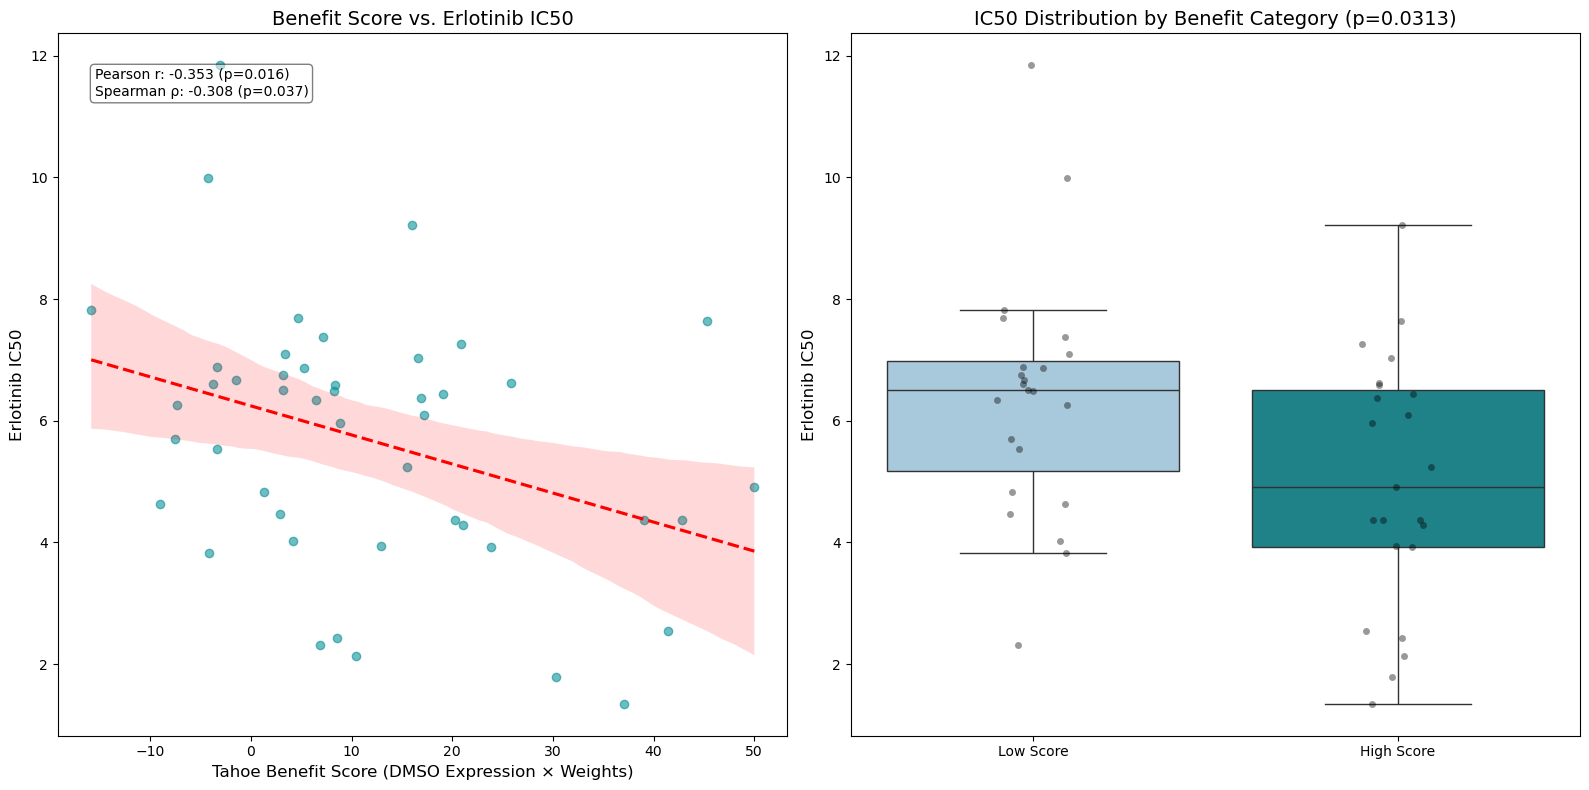

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

# ==========================================
# 1. Prepare Data Alignment
# ==========================================

# A. Create a mapping between CVCL ID and Stripped Name from the Tahoe Data
# (Based on the snippet you provided)
name_mapping = df_dmso_clean[['cell_line', 'StrippedCellLineName']].drop_duplicates()
name_mapping = name_mapping.set_index('cell_line')['StrippedCellLineName']

# B. Extract Erlotinib IC50 values
# Assuming index is drug names and columns are stripped cell line names
erlotinib_ic50 = Ic50.loc['ERLOTINIB'].dropna()

# C. Convert Average Benefit Scores (from previous step) to a DataFrame
# avg_benefit_scores was indexed by CVCL ID
benefit_df = avg_benefit_scores.to_frame(name='benefit_score')
benefit_df['StrippedCellLineName'] = benefit_df.index.map(name_mapping)

# D. Merge Benefit Scores with IC50 values
# We join on the Stripped Name
comparison_df = benefit_df.merge(
    erlotinib_ic50.to_frame(name='ic50'), 
    left_on='StrippedCellLineName', 
    right_index=True, 
    how='inner'
)

# E. Re-calculate Categories based on the median of this specific overlap
median_val = comparison_df['benefit_score'].median()
comparison_df['Category'] = comparison_df['benefit_score'].apply(
    lambda x: 'High Score' if x > median_val else 'Low Score'
)

print(f"Number of cell lines matching between Tahoe and IC50: {len(comparison_df)}")

# ==========================================
# 2. Visualization
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 1: Scatter Plot (Correlation) ---
sns.regplot(
    data=comparison_df, 
    x='benefit_score', 
    y='ic50', 
    ax=ax1, 
    scatter_kws={'alpha':0.6, 'color':'#0c919a'},
    line_kws={'color':'red', 'linestyle':'--'}
)

# Calculate Correlations
p_corr, p_pval = pearsonr(comparison_df['benefit_score'], comparison_df['ic50'])
s_corr, s_pval = spearmanr(comparison_df['benefit_score'], comparison_df['ic50'])

corr_text = f"Pearson r: {p_corr:.3f} (p={p_pval:.3f})\nSpearman ρ: {s_corr:.3f} (p={s_pval:.3f})"
ax1.text(0.05, 0.95, corr_text, transform=ax1.transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax1.set_title('Benefit Score vs. Erlotinib IC50', fontsize=14)
ax1.set_xlabel('Tahoe Benefit Score (DMSO Expression × Weights)', fontsize=12)
ax1.set_ylabel('Erlotinib IC50', fontsize=12)

# --- Plot 2: Boxplot (Categorical Difference) ---
palette = {'High Score': '#0c919a', 'Low Score': '#9fcae3'}
sns.boxplot(
    data=comparison_df, 
    x='Category', 
    y='ic50', 
    order=['Low Score', 'High Score'],
    palette=palette, 
    ax=ax2, 
    showfliers=False
)
sns.stripplot(
    data=comparison_df, 
    x='Category', 
    y='ic50', 
    order=['Low Score', 'High Score'],
    color='black', 
    alpha=0.4, 
    ax=ax2
)

# Statistical Test (Mann-Whitney U)
high_vals = comparison_df[comparison_df['Category'] == 'High Score']['ic50']
low_vals = comparison_df[comparison_df['Category'] == 'Low Score']['ic50']
u_stat, u_pval = mannwhitneyu(high_vals, low_vals, alternative='two-sided')

ax2.set_title(f'IC50 Distribution by Benefit Category (p={u_pval:.4f})', fontsize=14)
ax2.set_ylabel('Erlotinib IC50', fontsize=12)
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

# Optional: Save the merged data for inspection
# comparison_df.to_csv("tahoe_vs_ic50_erlotinib.csv")

In [35]:
Exp = pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv")

In [36]:
Exp

,StrippedCellLineName,A1BG,A1BG-AS1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,127399,1.335851,2.837184,-0.475762,3.522372,5.289224,5.436261,1.912285,6.170977,5.486915,...,6.255815,7.125433,0.970038,3.911810,3.513628,3.671321,5.387186,7.657886,4.690012,5.671180
1,143B,0.505021,1.146315,4.020641,2.191379,5.726666,3.992820,3.975156,6.908841,4.667542,...,7.219736,7.134179,1.487684,4.076379,4.290047,3.913427,4.413880,7.452491,5.690861,6.489629
2,170MGBA,-6.343651,-1.951334,7.934532,3.568739,4.676171,4.810112,2.668508,6.323091,6.443912,...,5.663259,4.028126,2.966962,4.290252,4.614660,-7.928613,6.486930,7.582614,6.399150,7.430827
3,22RV1,-0.050892,2.802209,2.974042,-2.257672,6.130935,6.428204,3.251642,6.020554,6.088325,...,6.658125,7.350443,1.131819,3.456761,4.554439,-1.247825,5.552063,4.451671,5.854928,5.957179
4,2313287,-4.772263,-1.602338,-4.772263,1.264826,5.211839,4.931832,-4.241749,6.394806,5.462554,...,6.162984,6.500690,1.941982,4.451470,4.655631,-3.854726,5.514551,5.788176,5.886246,6.400234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,YKG1,2.210062,2.674504,-0.001606,-0.197702,5.275358,4.750419,2.750956,5.965220,5.832130,...,5.441393,6.409373,1.758811,3.244542,4.126711,-0.070790,5.321407,7.582778,6.322552,5.541438
1072,YSCCC,1.870461,2.358508,-2.643949,4.055734,5.525703,4.728085,1.692335,7.503464,7.135592,...,4.463245,2.963247,2.850234,4.914124,5.548837,2.618402,5.521141,6.069610,5.496997,6.646531
1073,YUHOIN,0.982084,2.992300,9.176230,-1.138372,5.258762,5.565648,3.073270,6.688462,6.244944,...,6.287610,6.349423,1.617115,3.624896,3.823126,2.856553,5.436593,8.180691,5.596718,6.613736
1074,Z138,0.482552,2.864074,-4.637542,1.569744,6.342360,6.238549,-7.807467,6.356576,4.007516,...,6.208036,7.087399,1.428548,4.321494,4.515870,-7.807467,5.276511,-2.598013,6.343788,6.294099


Calculating Benefit Scores for DepMap...
  > Genes used for DepMap scoring: 201
Number of overlapping cell lines found: 37


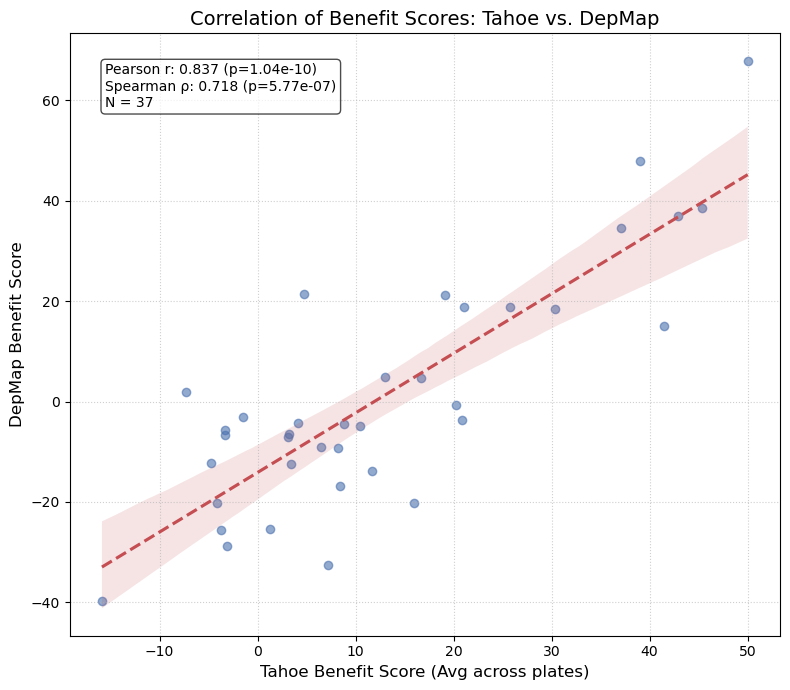

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# ==========================================
# 1. Calculate Benefit Score for DepMap
# ==========================================
print("Calculating Benefit Scores for DepMap...")

# Assuming df_depmap is your DepMap DataFrame
if 'StrippedCellLineName' in Exp.columns:
    depmap_exp = Exp.set_index('StrippedCellLineName')
else:
    depmap_exp = Exp

# Ensure weights are loaded (using the same 'weights_aligned' from your Tahoe script)
# If weights_aligned isn't in memory, reload from WEIGHTS_PATH as you did before:
# gene_weights = pd.read_csv(WEIGHTS_PATH, index_col=0)
# weights = gene_weights['scaled_combined'] # or your specific column

# Find overlap between DepMap genes and the weights
common_depmap_genes = Exp.columns.intersection(weights.index)
print(f"  > Genes used for DepMap scoring: {len(common_depmap_genes)}")

# Compute Raw Scores for DepMap
depmap_benefit_scores = depmap_exp[common_depmap_genes].dot(weights.loc[common_depmap_genes])

# ==========================================
# 2. Align Tahoe and DepMap Scores
# ==========================================

# A. Prepare Tahoe scores (mapped to Stripped Names)
# We use the name_mapping from the Tahoe metadata to convert CVCL to Stripped names
tahoe_mapped_scores = avg_benefit_scores.to_frame(name='tahoe_score')
tahoe_mapped_scores['StrippedCellLineName'] = tahoe_mapped_scores.index.map(name_mapping)

# B. Prepare DepMap scores
depmap_scores_df = depmap_benefit_scores.to_frame(name='depmap_score')

# C. Merge on StrippedCellLineName
comparison_df = tahoe_mapped_scores.merge(
    depmap_scores_df, 
    left_on='StrippedCellLineName', 
    right_index=True, 
    how='inner'
)

print(f"Number of overlapping cell lines found: {len(comparison_df)}")

# ==========================================
# 3. Correlation Analysis & Visualization
# ==========================================

if len(comparison_df) > 1:
    # Calculate Correlations
    p_corr, p_pval = pearsonr(comparison_df['tahoe_score'], comparison_df['depmap_score'])
    s_corr, s_pval = spearmanr(comparison_df['tahoe_score'], comparison_df['depmap_score'])

    plt.figure(figsize=(8, 7))
    sns.regplot(
        data=comparison_df, 
        x='tahoe_score', 
        y='depmap_score', 
        scatter_kws={'alpha':0.6, 'color':'#4C72B0'},
        line_kws={'color':'#C44E52', 'linestyle':'--'}
    )

    # Add text box with stats
    stats_text = (f"Pearson r: {p_corr:.3f} (p={p_pval:.2e})\n"
                  f"Spearman ρ: {s_corr:.3f} (p={s_pval:.2e})\n"
                  f"N = {len(comparison_df)}")
    
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    plt.title('Correlation of Benefit Scores: Tahoe vs. DepMap', fontsize=14)
    plt.xlabel('Tahoe Benefit Score (Avg across plates)', fontsize=12)
    plt.ylabel('DepMap Benefit Score', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: No overlapping cell lines found between Tahoe and DepMap. Check naming conventions.")

# Optional: Z-score comparison if the absolute values differ significantly in scale
# comparison_df['tahoe_z'] = (comparison_df['tahoe_score'] - comparison_df['tahoe_score'].mean()) / comparison_df['tahoe_score'].std()
# comparison_df['depmap_z'] = (comparison_df['depmap_score'] - comparison_df['depmap_score'].mean()) / comparison_df['depmap_score'].std()

In [40]:
comparison_df.shape

(37, 3)

In [20]:
common_cell_lines = (
    set(Exp["StrippedCellLineName"])
    & set(df_dmso_clean["StrippedCellLineName"])
)

len(common_cell_lines)


37

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


In [22]:
# Common cell lines
common_cell_lines = (
    set(Exp["StrippedCellLineName"])
    & set(df_dmso_clean["StrippedCellLineName"])
)

# Common genes (exclude metadata columns)
meta_cols = {"StrippedCellLineName", "plate", "cell_line"}
common_genes = (
    set(Exp.columns)
    & set(df_dmso_clean.columns)
    - meta_cols
)

common_genes = sorted(common_genes)


In [23]:
len(common_genes)

15076

In [24]:
exp_sub = Exp[
    Exp["StrippedCellLineName"].isin(common_cell_lines)
].set_index("StrippedCellLineName")

dmso_sub = df_dmso_clean[
    df_dmso_clean["StrippedCellLineName"].isin(common_cell_lines)
]


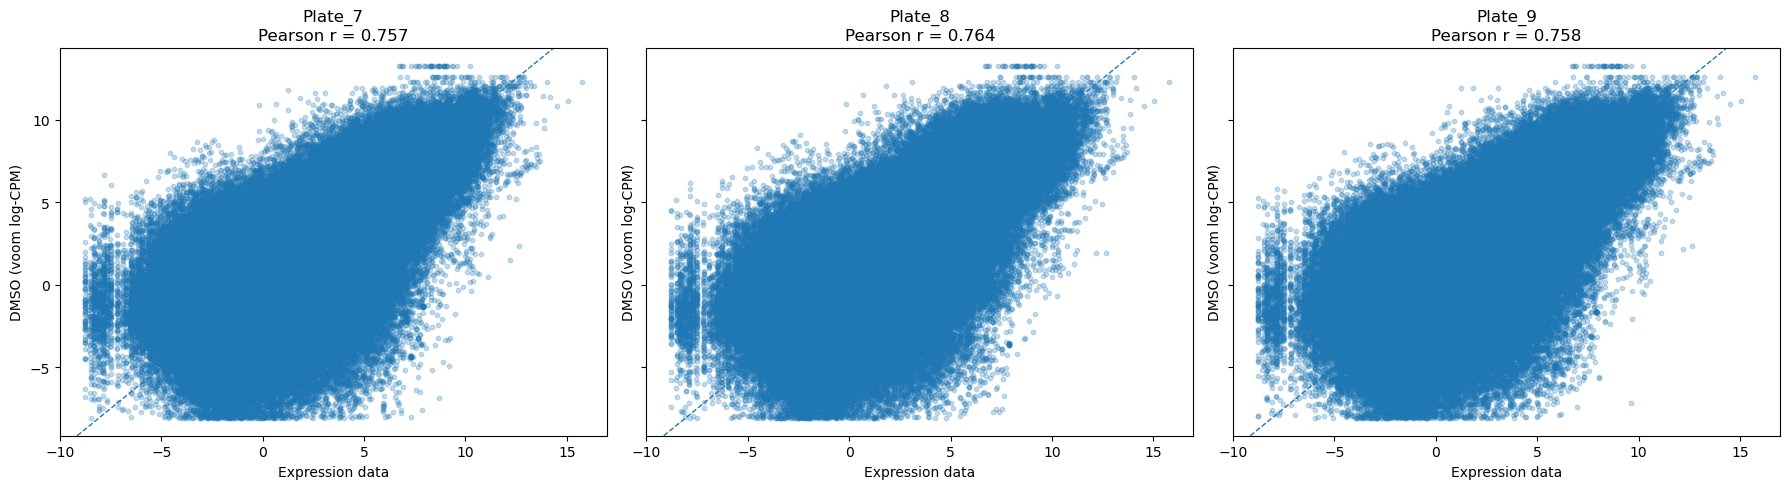

In [25]:
plates = ["Plate_7", "Plate_8", "Plate_9"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, plate in zip(axes, plates):

    dmso_plate = (
        dmso_sub[dmso_sub["plate"] == plate]
        .set_index("StrippedCellLineName")
    )

    # Align cell lines
    aligned_cells = exp_sub.index.intersection(dmso_plate.index)

    x = exp_sub.loc[aligned_cells, common_genes].values.flatten()
    y = dmso_plate.loc[aligned_cells, common_genes].values.flatten()

    r, _ = pearsonr(x, y)

    ax.scatter(x, y, alpha=0.25, s=10)
    ax.axline((0, 0), slope=1, linestyle="--", linewidth=1)
    ax.set_title(f"{plate}\nPearson r = {r:.3f}")
    ax.set_xlabel("Expression data")
    ax.set_ylabel("DMSO (voom log-CPM)")

plt.tight_layout()
plt.show()


### Corr for 187 genes model scaled